In [1]:
#importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Carregar os dados
df = pd.read_csv ('netflix_titles.csv')

#ver as primeiras 05 linhas
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
#Tamanho das linhas e colunas
print(f"O dataset te {df.shape[0]} linhas e {df.shape[1]} colunas")

#informações gerais
df.info()

O dataset te 8807 linhas e 12 colunas
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [3]:
#Quantos filmes e quantas séries
tipo_conteudo = df['type'].value_counts()
tipo_percent = df['type'].value_counts(normalize = True) * 100

print('Quantidade: ')
print(tipo_conteudo)
print('\nPercentual: ')
print(tipo_percent.round(1))

Quantidade: 
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Percentual: 
type
Movie      69.6
TV Show    30.4
Name: proportion, dtype: float64


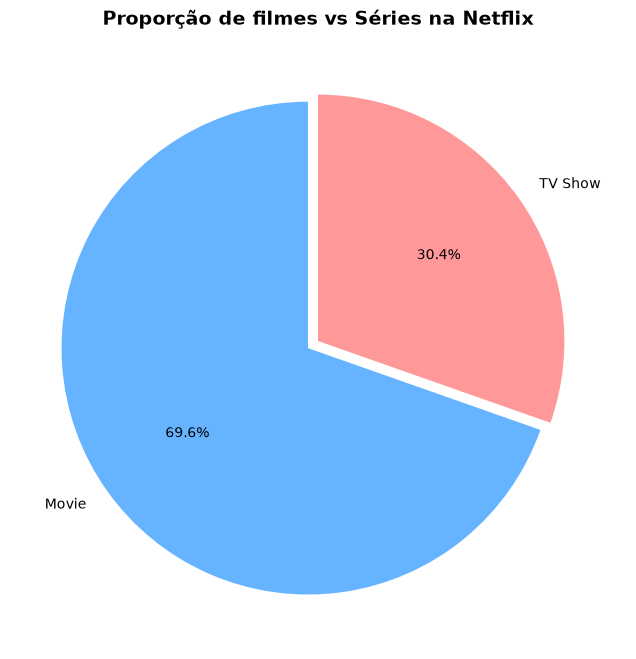

In [5]:
#Gráfico de Pizza
plt.figure(figsize = (8, 8))
cores = ['#66b3ff', '#ff9999']

plt.pie (tipo_conteudo, labels = tipo_conteudo.index, autopct = '%1.1f%%',
         startangle = 90, colors = cores, explode = (0.05, 0))
plt.title ('Proporção de filmes vs Séries na Netflix', fontsize = 14, fontweight = 'bold')
plt.savefig ('filmes_vs_series.png', dpi = 100, bbox_inches = 'tight')
plt.show()

In [7]:
#Quantos titulos de ano por lançamento
lancamentos_ano = df['release_year'].value_counts().sort_index()

#Ver ultimos 20 anos (2005-2021)
lancamentos_recentes = lancamentos_ano [lancamentos_ano.index >= 2005]

print('Top com mais 5 anos de lançamentos: ')
print(lancamentos_recentes.tail(5))

Top com mais 5 anos de lançamentos: 
release_year
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


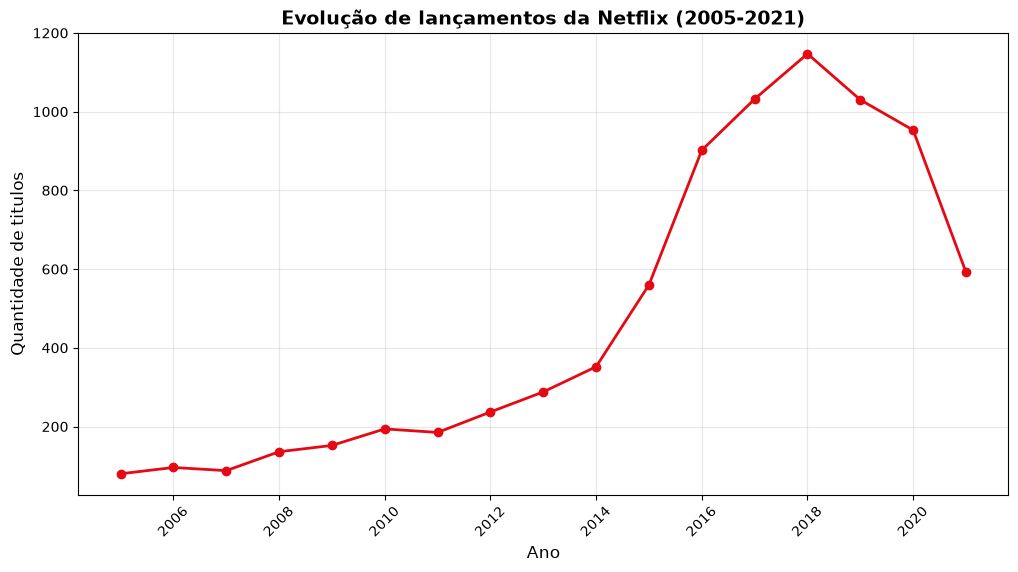

In [14]:
#Gráfico de linha
plt.figure (figsize=(12, 6))

plt.plot (lancamentos_recentes.index, lancamentos_recentes.values, marker = 'o', linewidth = 2, markersize = 6, color = '#E50914')

plt.title ('Evolução de lançamentos da Netflix (2005-2021)', fontsize = 14, fontweight = 'bold')
plt.xlabel ('Ano', fontsize = 12)
plt.ylabel ('Quantidade de titulos', fontsize = 12)
plt.grid (True, alpha = 0.3)
plt.xticks (rotation = 45)

plt.savefig ('evolucao_lancamentos.png', dpi = 100, bbox_inches = 'tight')
plt.show()

In [16]:
#Produções por país
paises = df ['country'].value_counts().head(10)

print('Top 10 paises que produzem conteúdos na Netflix')
print(paises)

Top 10 paises que produzem conteúdos na Netflix
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


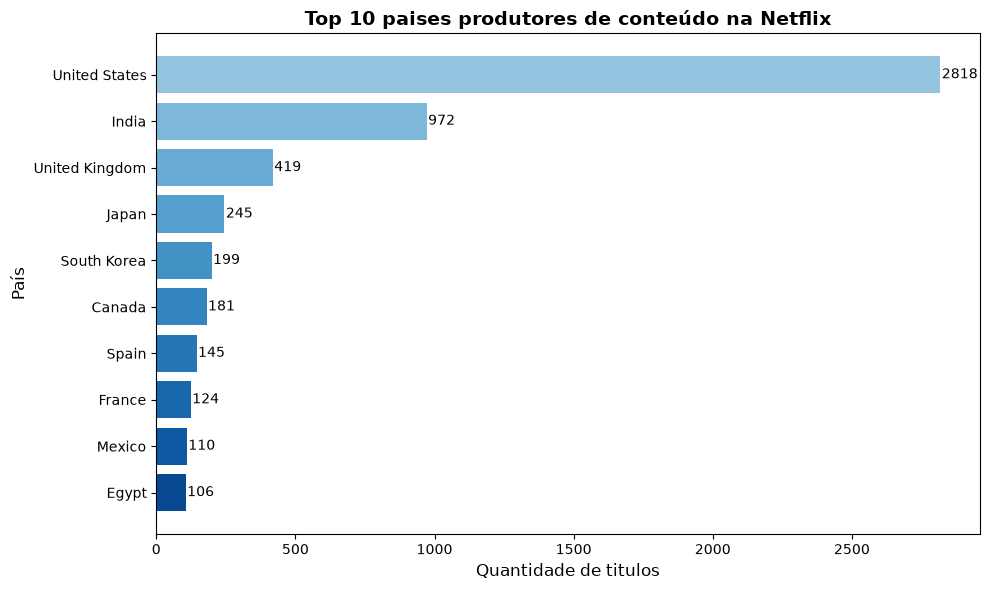

In [19]:
#Gráfico de barras
plt.figure (figsize = (10, 6))

cores = plt.cm.Blues (np.linspace (0.4, 0.9, len(paises)))
plt.barh (paises.index, paises.values, color = cores)

plt.title ('Top 10 paises produtores de conteúdo na Netflix', fontsize = 14, fontweight = 'bold')
plt.xlabel ('Quantidade de titulos', fontsize = 12)
plt.ylabel ('País', fontsize = 12)
plt.gca().invert_yaxis() #Inverter, mostrar o maior em cima.

#Adicionar valores nas barras
for i, v in enumerate (paises.values):
    plt.text (v + 5, i, str(v), va = 'center', fontsize = 10)

plt.tight_layout()
plt.savefig ('Top_paises.png', dpi = 100, bbox_inches = 'tight')
plt.show()

In [20]:
with open('README.md', 'w', encoding='utf-8') as arquivo:
    arquivo.write('# Analise de Conteudo Netflix\n\n')
    arquivo.write('## Visao Geral\n')
    arquivo.write('Analise do catalogo da Netflix com dados reais (8.800+ titulos)\n\n')
    arquivo.write('## Principais Descobertas\n\n')
    arquivo.write('### 1. Filmes vs Series\n')
    arquivo.write('- **Filmes:** 69.9%\n')
    arquivo.write('- **Series:** 30.1%\n\n')
    arquivo.write('### 2. Evolucao de Lancamentos\n')
    arquivo.write('![Evolucao](evolucao_lancamentos.png)\n')
    arquivo.write('Crescimento acelerado a partir de 2015\n\n')
    arquivo.write('### 3. Top Paises Produtores\n')
    arquivo.write('![Top Paises](top_paises.png)\n')
    arquivo.write('1. Estados Unidos\n')
    arquivo.write('2. India\n')
    arquivo.write('3. Reino Unido\n\n')
    arquivo.write('## Ferramentas\n')
    arquivo.write('- Python (Pandas, Matplotlib, Seaborn)\n')
    arquivo.write('- Jupyter Notebook\n')

print("README criado com sucesso!")

README criado com sucesso!
